In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# 1. DATASET
# ============================================================

housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Dimensiones:", df.shape)
print("\nPrimeras filas:")
print(df.head())
print("\nVariables:")
print(df.columns.tolist())
print("\nValores nulos:")
print(df.isnull().sum())

# Usamos MedInc para visualizar la relación con el precio medio de la vivienda
# Esta variable produce una nube de puntos más clara y coherente que HouseAge
X = df[["MedInc"]]
y = df["MedHouseVal"]

# ============================================================
# 2. MODELOS
# ============================================================

modelos = {
    "Lineal": Pipeline([
        ("regresion", LinearRegression())
    ]),

    "Polinomial grado 2": Pipeline([
        ("polinomio", PolynomialFeatures(degree=2)),
        ("regresion", LinearRegression())
    ]),

    "Polinomial grado 3": Pipeline([
        ("polinomio", PolynomialFeatures(degree=3)),
        ("regresion", LinearRegression())
    ]),

    "Logarítmico": Pipeline([
        ("log", FunctionTransformer(np.log)),
        ("regresion", LinearRegression())
    ])
}

# ============================================================
# 3. CROSS-VALIDATION
# ============================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

resultados = []

for nombre, modelo in modelos.items():

    scores = cross_validate(
        modelo,
        X,
        y,
        cv=kf,
        scoring={
            "R2": "r2",
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error"
        }
    )

    resultados.append({
        "Modelo": nombre,
        "R² promedio": scores["test_R2"].mean(),
        "R² std": scores["test_R2"].std(),
        "MAE promedio": -scores["test_MAE"].mean(),
        "RMSE promedio": -scores["test_RMSE"].mean()
    })

resultados = pd.DataFrame(resultados)

print("\nRESULTADOS - 5 FOLD CROSS-VALIDATION")
print(resultados.round(4))

Dimensiones: (20640, 9)

Primeras filas:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Variables:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Valores nulos:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

RESULTADOS - 5 FOLD CROSS

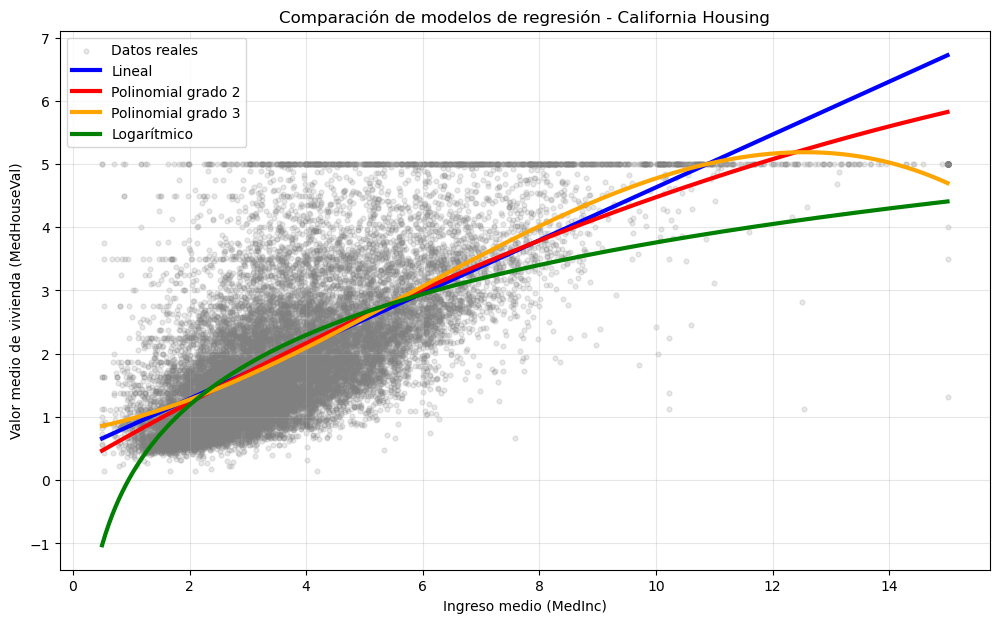

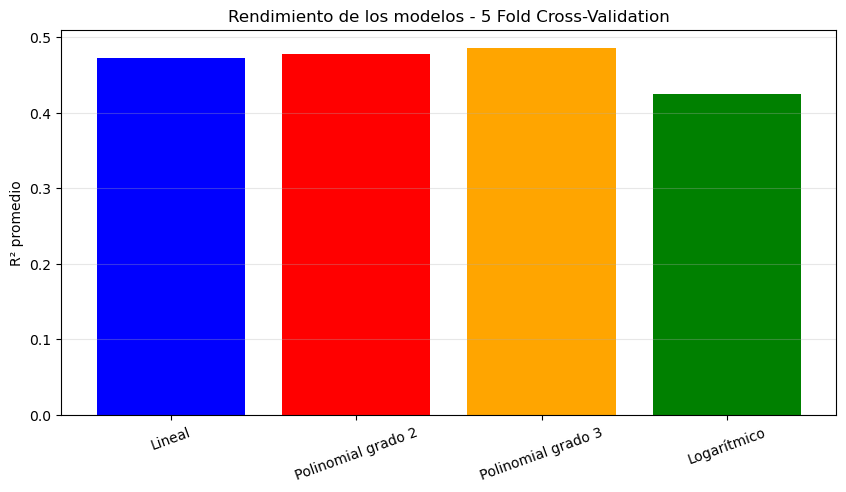

In [13]:
# ============================================================
# 4. AJUSTAR MODELOS COMPLETOS
# ============================================================

for modelo in modelos.values():
    modelo.fit(X, y)

# Valores para dibujar las líneas
x_plot = np.linspace(
    X["MedInc"].min(),
    X["MedInc"].max(),
    500
).reshape(-1, 1)

x_plot_df = pd.DataFrame(x_plot, columns=["MedInc"])

# ============================================================
# 5. GRÁFICA
# ============================================================

plt.figure(figsize=(12, 7))

# Datos reales
plt.scatter(
    X["MedInc"],
    y,
    alpha=0.18,
    s=12,
    color="gray",
    label="Datos reales"
)

# Líneas
colores = {
    "Lineal": "blue",
    "Polinomial grado 2": "red",
    "Polinomial grado 3": "orange",
    "Logarítmico": "green"
}

for nombre, modelo in modelos.items():

    y_pred = modelo.predict(x_plot_df)

    plt.plot(
        x_plot,
        y_pred,
        linewidth=3,
        color=colores[nombre],
        label=nombre
    )

plt.xlabel("Ingreso medio (MedInc)")
plt.ylabel("Valor medio de vivienda (MedHouseVal)")
plt.title("Comparación de modelos de regresión - California Housing")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ============================================================
# 6. GRÁFICA DE R² DE CROSS-VALIDATION
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    resultados["Modelo"],
    resultados["R² promedio"],
    color=["blue", "red", "orange", "green"]
)

plt.ylabel("R² promedio")
plt.title("Rendimiento de los modelos - 5 Fold Cross-Validation")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.show()

# Comparación de modelos de regresión — California Housing

## 1. Dataset: California Housing

`California Housing` es un dataset de **regresión** basado en datos del censo de California de 1990.

Cada fila representa un **grupo de bloques censales** y contiene información demográfica, geográfica y de vivienda.

- **20.640 observaciones**
- **8 variables predictoras**
- **1 variable objetivo**
- No contiene valores faltantes.

### Variables principales

| Variable | Descripción |
|---|---|
| `MedInc` | Ingreso medio |
| `HouseAge` | Edad media de las viviendas |
| `AveRooms` | Número medio de habitaciones |
| `AveBedrms` | Número medio de dormitorios |
| `Population` | Población |
| `AveOccup` | Ocupación media |
| `Latitude` | Latitud |
| `Longitude` | Longitud |
| `MedHouseVal` | Valor medio de las viviendas (**objetivo**) |

En este ejercicio utilizamos principalmente:

`MedInc → MedHouseVal`

para poder visualizar y comparar las líneas de estimación de los diferentes modelos.

---

# 2. Modelos de regresión

## Regresión lineal

Busca representar una relación aproximadamente **recta** entre las variables.

**Idea:**
> Cuando X aumenta, Y cambia aproximadamente a un ritmo constante.

### Se usa cuando:
- La relación entre las variables es aproximadamente lineal.
- Se necesita un modelo sencillo e interpretable.
- Se quiere establecer una relación general entre variables.

### No es ideal cuando:
- La relación es claramente curva.
- Existen patrones complejos que una línea no puede representar.

### Analogía

Es como colocar una **regla** sobre un conjunto de puntos intentando que represente la tendencia general.

---

## Regresión polinomial

Extiende la regresión lineal permitiendo crear **curvas**.

Puede utilizar términos como:

`x²`, `x³`, `x⁴`, etc.

### Se usa cuando:
- Los datos presentan una relación curva.
- Una línea recta no representa suficientemente bien los datos.
- Se necesita mayor flexibilidad.

### No es ideal cuando:
- El grado del polinomio es demasiado alto.
- El modelo empieza a ajustarse demasiado a los datos de entrenamiento (**overfitting**).
- Se busca máxima simplicidad e interpretabilidad.

### Analogía

En lugar de colocar una regla sobre los puntos, utilizamos una **manguera flexible** que puede adaptarse a la forma de los datos.

---

## Regresión logarítmica

Transforma la variable independiente utilizando `log(x)`.

La relación permite representar situaciones donde el efecto de X es grande al principio y después **va disminuyendo**.

### Se usa cuando:
- Los primeros cambios de X tienen mucho efecto sobre Y.
- El efecto de X disminuye progresivamente.
- Los datos presentan una tendencia que se parece a una curva logarítmica.

### No es ideal cuando:
- La relación no tiene comportamiento logarítmico.
- Existen valores de X iguales o menores que cero, ya que `log(x)` no está definido para ellos.

### Analogía

Es como empujar una puerta: al principio un pequeño movimiento puede cambiar mucho la posición, pero después cada movimiento adicional produce un efecto relativamente menor.

---

# 3. ¿Qué es Cross-Validation?

**Cross-Validation (validación cruzada)** es una técnica para comprobar si un modelo puede **generalizar correctamente a datos que no ha visto**.

En lugar de entrenar y evaluar el modelo una sola vez, dividimos los datos varias veces.

En este ejercicio usamos **5-Fold Cross-Validation**:

```text
Datos completos
      ↓
┌─────┬─────┬─────┬─────┬─────┐
│ F1  │ F2  │ F3  │ F4  │ F5  │
└─────┴─────┴─────┴─────┴─────┘

Iteración 1 → F1 prueba / F2-F5 entrenamiento
Iteración 2 → F2 prueba / F1,F3-F5 entrenamiento
Iteración 3 → F3 prueba / resto entrenamiento
Iteración 4 → F4 prueba / resto entrenamiento
Iteración 5 → F5 prueba / resto entrenamiento